In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ps2mult1.csv

Your assignment asked to:
Perform multiple regression from scratch
Using dataset ps2mult1.csv
Fit the model: 
    ​y^​=β^​0​+β^​1​x1​+β^​2​x2​

Compute residuals
Report min and max residual
Plot histogram of residuals

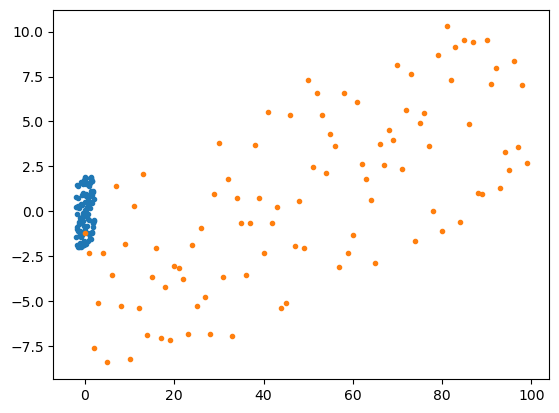

In [173]:
df1 = pd.read_csv('/Users/srisuphachawla/Downloads/ps2mult1.csv', header = None)
plt.plot(df1[0], df1[1], '.')
plt.plot(df1[2], '.')


In [ ]:
# np._c --> column wise concatenation which stacks arrays side by side
# np.ones --> you want the first matrix of x to be ones, otherwise you would be forcing beta_0 = 0, which is usually wrong
Y1 = np.array(df1.iloc[:,2])
X1 = np.c_[np.ones(len(Y1)), np.array(df1.iloc[:, 0:2])]

# now, we completed creating the matrix form of y = Xb + E (residual)

In [ ]:
# now our matrix form is supposed to work for OLS where X = sum(y - y_bar)**2 is minimized
# in matrix form --> Beta_hat = (Xt. X) @ (Xt. y)

# X1.T = Transpose of matrix X1
# Compute beta estimates using Normal Equation
# beta = (X'X)^(-1) X'y

b_hat_1 = np.linalg.inv(X1.T @ X1) @ (X1.T @ Y1)
print(b_hat_1[0], b_hat_1[1], b_hat_1[2])


0.9876808031335284 2.077501015004638 3.016189364129115


# Residuals

In [ ]:
Y_fit = X1@b_hat_1
e1 = Y1 - Y_fit

In [89]:
print(f'Min: {min(e1)}')
print(f'Max: {max(e1)}')

Min: -0.9288486791979174
Max: 1.2558664704664824


# Histogram

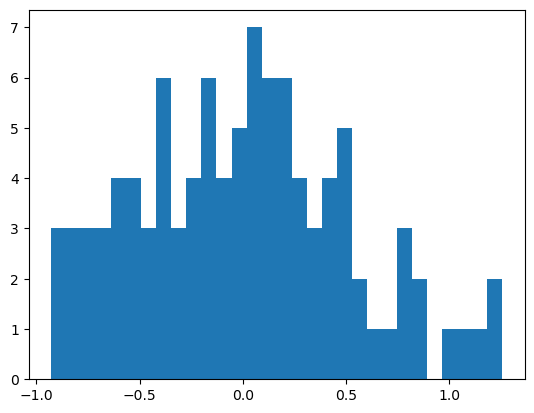

In [95]:
plt.hist(e1, bins = 30);

# ps2mult2.csv

In [174]:
# Since this graph is hyperbolic, we will need to tweak our formula a bit by adding 1/x
df2 = pd.read_csv("/Users/srisuphachawla/Downloads/ps2mult2.csv", header = None)
df2


,0,1
0,3.141178,9.089193
1,0.259382,19.511052
2,2.378476,7.271792
3,1.930502,8.824064
4,0.766721,9.438270
...,...,...
495,1.180479,9.674211
496,2.987282,7.164748
497,0.891963,9.325351
498,1.095044,8.952246


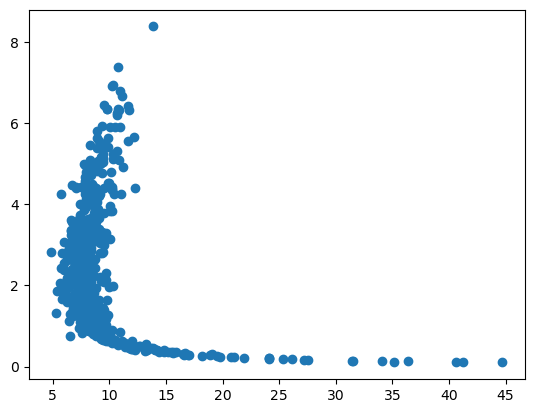

In [175]:
plt.plot(df2[1], df2[0], 'o')

In [123]:
# Step 2: Extract response variable (Y) and predictors (X)
Y2 = np.array(df2[1])
X_normal = np.array(df2[0])
x_inverse = 1/X_normal
X2 = np.c_[np.ones(len(Y2)), np.c_[X_normal, x_inverse]]


In [124]:
B_hat_2 = np.linalg.inv(X2.T @ X2) @ (X2.T @ Y2)
(B_hat_2[0], B_hat_2[1], B_hat_2[2])

(np.float64(3.4425418309382056),
 np.float64(1.0024625080898857),
 np.float64(4.045378830871115))

In [176]:
xs = np.linspace(0.1, 8, 500)
y_plot = [B_hat_2[0] + B_hat_2[1] * x + B_hat_2[2] * (1/x) for x in xs]


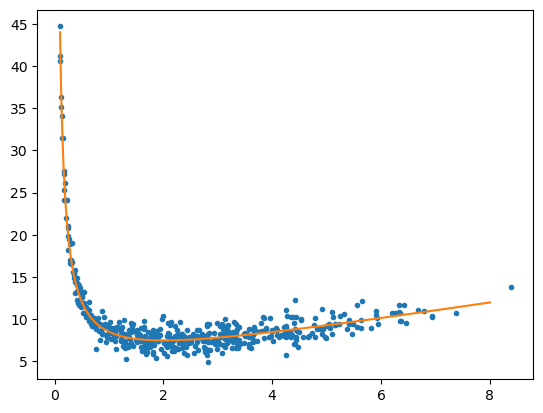

In [138]:
plt.plot(df2[0], df2[1], '.')
plt.plot(xs, y_plot)


In [177]:
Y_fit_2 = X2@B_hat_2
e2 = Y2 - Y_fit_2
print(f'Min: {min(e2)}')
print(f'Max: {max(e2)}')

Min: -3.0523854235036563
Max: 3.4527874227260043


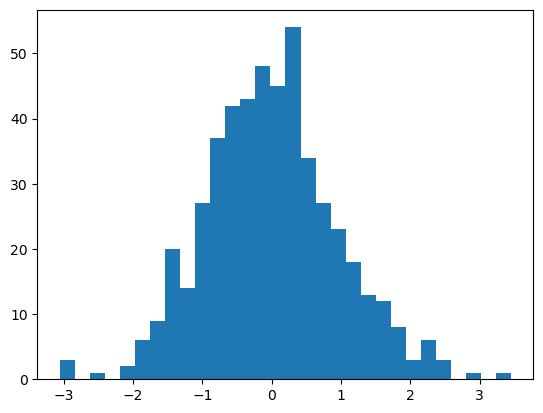

In [143]:
plt.hist(e2, bins = 30);

File 3


In [147]:
df3 = pd.read_csv('/Users/srisuphachawla/Documents/DataScienceNotes/Datasets/ps2mult3.csv', header = None)
df3

,0,1,2
0,1.986735,3.880583,5.539968
1,0.565305,1.304131,1.092732
2,-3.598600,-1.892916,-0.653892
3,-2.142767,4.632153,43.686741
4,0.553690,-0.900932,2.651475
...,...,...,...
195,-1.956283,1.719559,11.468632
196,-3.593261,-3.519690,-3.588388
197,0.516270,2.945634,6.513927
198,1.440949,0.166126,3.058118


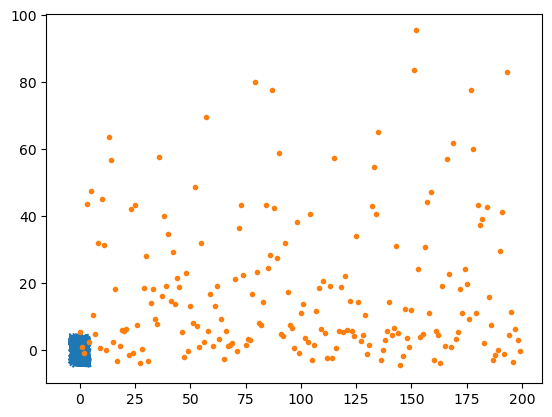

In [178]:
plt.plot(df3[0], df3[1], df3[2], '.')


In [ ]:
Y3 = np.array(df3[2])
X3 = np.c_[np.ones(len(Y3)), np.array(df3.iloc[:, 0:2])]

beta_3 = np.linalg.inv(X3.T@ X3) @ (X3.T@Y3)
print(beta_3[0], beta_3[1], beta_3[2])

17.890569724608813 0.38423735727755454 0.8185666457180593


In [183]:
Y_hat = X3@beta_3

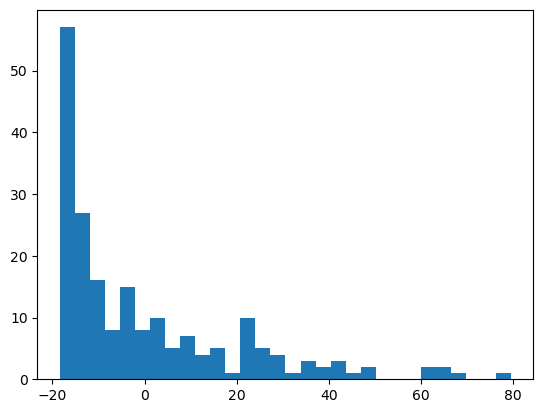

In [184]:
e3 = Y3 - Y_hat
plt.hist(e3, bins = 30);


In [185]:
# Bad graph above, we are try quadratic way
# so, we get all the polynomial terms necessary for a quadratic equation
X_squared = df3[0]**2
Y_squared = df3[1]**2
XY = df3[0] * df3[1]

input_quad = np.c_[
    np.ones(len(Y3)),
    X_squared,
    XY,
    Y_squared,
    df3[0],
    df3[1]               
]

In [186]:
quad_b3_hat = np.linalg.inv(input_quad.T@ input_quad) @ (input_quad.T@Y3)
print(quad_b3_hat[0],
      quad_b3_hat[1],
      quad_b3_hat[2],
      quad_b3_hat[3],
      quad_b3_hat[4],
      quad_b3_hat[5],
      )

-0.003005831052003276 1.000661269683947 -1.9997958585570133 0.9996878627804893 1.003074262264702 0.00043674949473943036


In [187]:
beta_quad = input_quad @ quad_b3_hat

In [188]:
quad_e = Y3 - beta_quad
print(f'Min: {min(quad_e)}')
print(f'Max: {max(quad_e)}')

Min: -0.09903574044008145
Max: 0.10426001843327715


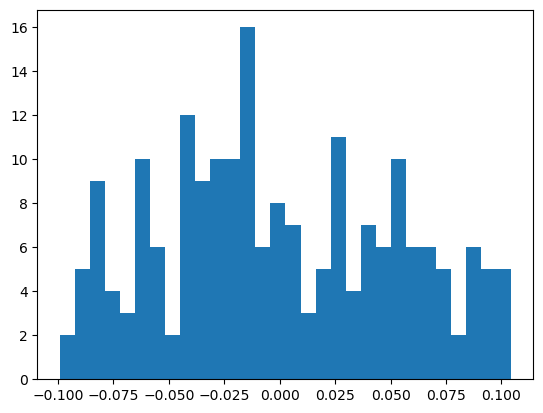

In [190]:
plt.hist(quad_e, bins = 30);